In [23]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

import statsmodels.formula.api as smf
from scipy.stats import binomtest, norm
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

In [24]:
def parse_patient_txt_file(txt_file_path: Path) -> dict[str, str]:
    """Parse a patient text file of `Key: Value` rows.
    Args:
            txt_file_path: Path to one patient .txt file.
    Returns:
            A dictionary where keys are field names and values are raw string values.
    Raises:
            OSError: If the file cannot be read.
    """
    record: dict[str, str] = {}
    for raw_line in txt_file_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line:
            continue
        if ":" not in line:
            continue
        key, value = line.split(":", maxsplit=1)
        record[key.strip()] = value.strip()
    record["source_file"] = str(txt_file_path)
    return record


def build_training_dataframe(training_root_path: Path) -> pd.DataFrame:
    """Load all patient text files into one pandas DataFrame.
    Args:
            training_root_path: Root path that contains patient folders and .txt files.
    Returns:
            A DataFrame with one row per file and one column per text field.
    """
    records: list[dict[str, str]] = []
    for txt_file_path in sorted(training_root_path.rglob("*.txt")):
        records.append(parse_patient_txt_file(txt_file_path))
    training_dataframe = pd.DataFrame.from_records(records)
    training_dataframe = normalize_string_missing_values(training_dataframe)
    return convert_column_types(training_dataframe)

def convert_column_types(training_dataframe: pd.DataFrame) -> pd.DataFrame:
    """Convert known columns to analysis-friendly dtypes.
    Args:
            training_dataframe: DataFrame created from patient text files.
    Returns:
            A DataFrame with converted numeric and boolean columns.
    """
    converted_dataframe = normalize_string_missing_values(training_dataframe)
    for numeric_column in ["Age", "TTM", "CPC", "ROSC"]:
        if numeric_column in converted_dataframe.columns:
            converted_dataframe[numeric_column] = pd.to_numeric(
                converted_dataframe[numeric_column],
                errors="coerce",
            )
    for bool_column in ["OHCA", "Shockable Rhythm"]:
        if bool_column in converted_dataframe.columns:
            converted_dataframe[bool_column] = converted_dataframe[bool_column].map(
                {"True": True, "False": False}
            )
    return converted_dataframe


def normalize_string_missing_values(training_dataframe: pd.DataFrame) -> pd.DataFrame:
    """Normalize literal string missing markers to pandas missing values.
    Args:
            training_dataframe: Raw dataframe created from patient text files or parquet.
    Returns:
            A dataframe where common string missing markers are converted to ``pd.NA``.
    """
    normalized_dataframe = training_dataframe.copy()
    missing_markers = {
        "": pd.NA,
        "nan": pd.NA,
        "NaN": pd.NA,
        "NAN": pd.NA,
        "none": pd.NA,
        "None": pd.NA,
        "NONE": pd.NA,
        "null": pd.NA,
        "Null": pd.NA,
        "NULL": pd.NA,
    }
    return normalized_dataframe.replace(missing_markers)

def prepare_modeling_features(
    input_dataframe: pd.DataFrame,
    numeric_fill_values: dict[str, float] | None = None,
) -> tuple[pd.DataFrame, dict[str, float]]:
    """Create model-ready features that keep rows with recorded missingness.
    Args:
            input_dataframe: Input dataframe containing the clinical predictors.
            numeric_fill_values: Optional fill values learned from training data.
    Returns:
            A tuple of the prepared dataframe and the numeric fill values used.
    """
    modeling_dataframe = input_dataframe.copy()
    if "Sex" in modeling_dataframe.columns:
        modeling_dataframe["Sex"] = modeling_dataframe["Sex"].fillna("Unknown")
    for bool_column in ["OHCA", "Shockable Rhythm"]:
        if bool_column in modeling_dataframe.columns:
            modeling_dataframe[bool_column] = (
                modeling_dataframe[bool_column]
                .map({True: "Yes", False: "No"})
                .fillna("Not recorded")
            )
    if "TTM" in modeling_dataframe.columns:
        modeling_dataframe["TTM"] = (
            modeling_dataframe["TTM"].map({33.0: "33C", 36.0: "36C"}).fillna("No TTM")
        )
    if numeric_fill_values is None:
        numeric_fill_values = {}
        for numeric_column in ["Age", "ROSC"]:
            if numeric_column in modeling_dataframe.columns:
                numeric_fill_values[numeric_column] = float(
                    modeling_dataframe[numeric_column].median()
                )
    for numeric_column in ["Age", "ROSC"]:
        if numeric_column in modeling_dataframe.columns:
            indicator_column = f"{numeric_column}_missing"
            modeling_dataframe[indicator_column] = (
                modeling_dataframe[numeric_column].isna().astype(int)
            )
            fill_value = numeric_fill_values[numeric_column]
            modeling_dataframe[numeric_column] = modeling_dataframe[
                numeric_column
            ].fillna(fill_value)
    return modeling_dataframe, numeric_fill_values

training_root_path = Path("icare_data") / "training"
training_dataframe = build_training_dataframe(training_root_path)


In [25]:
train_df, test_df = train_test_split(
    training_dataframe,
    test_size=0.2,
    stratify=training_dataframe["Outcome"],
    random_state=1234,
)

print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")

split_distribution = pd.concat(
    {
        "full": training_dataframe["Outcome"].value_counts(normalize=True).mul(100).round(2),
        "train": train_df["Outcome"].value_counts(normalize=True).mul(100).round(2),
        "test": test_df["Outcome"].value_counts(normalize=True).mul(100).round(2),
    },
    axis=1,
).fillna(0)

print("\nOutcome distribution (%):")
display(split_distribution)

Train rows: 485
Test rows: 122

Outcome distribution (%):


,full,train,test
Outcome,,,
Poor,62.93,62.89,63.11
Good,37.07,37.11,36.89


In [26]:
# Encode outcome labels as binary: Good=1, Poor=0
outcome_mapping = {"Poor": 0, "Good": 1}

training_dataframe = training_dataframe.copy()
train_df = train_df.copy()
test_df = test_df.copy()

training_dataframe["Outcome_binary"] = training_dataframe["Outcome"].map(outcome_mapping)
train_df["Outcome_binary"] = train_df["Outcome"].map(outcome_mapping)
test_df["Outcome_binary"] = test_df["Outcome"].map(outcome_mapping)

modeling_train_df, numeric_fill_values = prepare_modeling_features(train_df)
modeling_test_df, _ = prepare_modeling_features(
    test_df, numeric_fill_values=numeric_fill_values
)

y_train_binary = modeling_train_df["Outcome_binary"].astype(int)
y_test_binary = modeling_test_df["Outcome_binary"].astype(int)

print("Numeric fill values:", numeric_fill_values)

Numeric fill values: {'Age': 63.0, 'ROSC': 18.5}


In [27]:
exclude_columns = {
    "Outcome",
    "Outcome_binary",
    "source_file",
    "CPC",
    "Patient",
    "Hospital",
}

predictor_columns = [
    col for col in modeling_train_df.columns if col not in exclude_columns
]

formula_terms = [f'Q("{col}")' for col in predictor_columns]

formula = "Outcome_binary ~ " + " + ".join(formula_terms)


logit_model = smf.glm(
    formula=formula,
    data=modeling_train_df,
    family=sm.families.Binomial(link=sm.families.links.Logit()),
    missing="raise",
).fit(maxiter=100, tol=1e-8)


In [28]:
display(logit_model.summary().tables[0])

Dep. Variable:,Outcome_binary,No. Observations:,485
Model:,GLM,Df Residuals:,472
Model Family:,Binomial,Df Model:,12
Link Function:,Logit,Scale:,1.0000
Method:,IRLS,Log-Likelihood:,-265.58
Date:,"Sat, 11 Apr 2026",Deviance:,531.15
Time:,21:28:13,Pearson chi2:,480.
No. Iterations:,19,Pseudo R-squ. (CS):,0.2007
Covariance Type:,nonrobust,,


In [29]:
def clean_term_name(term_name: str) -> str:
    if term_name.startswith('Q("') and term_name.endswith('")'):
        return term_name[3:-2]
    return term_name


def compute_gvif_table(model_result, model_name: str) -> pd.DataFrame:
    """Compute GVIF and adjusted GVIF (GVIF^(1/(2*Df))) per model term."""
    exog_names = model_result.model.exog_names
    design_info = model_result.model.data.design_info

    # Remove intercept from the coefficient correlation matrix.
    kept_names = [name for name in exog_names if name != "Intercept"]
    cov_params = model_result.cov_params().loc[kept_names, kept_names]

    std = np.sqrt(np.diag(cov_params))
    corr_values = cov_params.to_numpy() / np.outer(std, std)
    corr_matrix = pd.DataFrame(corr_values, index=kept_names, columns=kept_names)

    sign_all, logdet_all = np.linalg.slogdet(corr_matrix.to_numpy())
    if sign_all <= 0:
        raise ValueError(
            f"Correlation matrix is not positive definite for {model_name}."
        )

    rows = []
    for term_name, term_slice in design_info.term_name_slices.items():
        if term_name == "Intercept":
            continue

        term_columns = [
            col for col in exog_names[term_slice] if col in corr_matrix.columns
        ]
        if not term_columns:
            continue

        other_columns = [col for col in corr_matrix.columns if col not in term_columns]

        sign_term, logdet_term = np.linalg.slogdet(
            corr_matrix.loc[term_columns, term_columns].to_numpy()
        )
        if sign_term <= 0:
            gvif = np.nan
        else:
            if other_columns:
                sign_other, logdet_other = np.linalg.slogdet(
                    corr_matrix.loc[other_columns, other_columns].to_numpy()
                )
                gvif = (
                    np.nan
                    if sign_other <= 0
                    else np.exp(logdet_term + logdet_other - logdet_all)
                )
            else:
                gvif = np.exp(logdet_term - logdet_all)

        df_term = len(term_columns)
        gvif_adjusted = gvif ** (1 / (2 * df_term))

        rows.append(
            {
                "Variable": clean_term_name(term_name),
                "Df": df_term,
                "GVIF": gvif,
                "GVIF^(1/(2*Df))": gvif_adjusted,
            }
        )
    return pd.DataFrame(rows)


gvif_long = pd.concat(
    [compute_gvif_table(logit_model, "Logit")],
    ignore_index=True,
)

display(gvif_long.round(3))

,Variable,Df,GVIF,GVIF^(1/(2*Df))
0,Sex,2,2.058,1.198
1,OHCA,2,2.930,1.308
2,Shockable Rhythm,2,3.408,1.359
3,TTM,2,1.914,1.176
4,Age,1,1.122,1.059
5,ROSC,1,1.052,1.026
6,Age_missing,1,2.000,1.414
7,ROSC_missing,1,1.243,1.115


In [30]:
# Evaluate logit model on test data without dropping rows for predictor missingness.
eval_columns = predictor_columns + ["Outcome_binary"]
logit_eval_df = modeling_test_df[eval_columns].copy()

if logit_eval_df["Outcome_binary"].isna().any():
    raise ValueError("Outcome_binary contains missing values in the evaluation set.")

y_true = logit_eval_df["Outcome_binary"].astype(int)
y_prob = logit_model.predict(logit_eval_df)
y_pred = (y_prob >= 0.5).astype(int)

n = len(y_true)
correct = int((y_pred == y_true).sum())
accuracy = correct / n

# Parametric (normal approximation) 95% CI for accuracy.
z_975 = norm.ppf(0.975)
se_accuracy = (accuracy * (1 - accuracy) / n) ** 0.5
acc_ci_low = max(0.0, accuracy - z_975 * se_accuracy)
acc_ci_high = min(1.0, accuracy + z_975 * se_accuracy)

# Dominant-class baseline on the evaluation sample.
dominant_class = int(y_true.mode().iloc[0])
dominant_accuracy = float((y_true == dominant_class).mean())

# One-sided test: H0 accuracy <= dominant_accuracy vs H1 accuracy > dominant_accuracy.
accuracy_test = binomtest(
    k=correct,
    n=n,
    p=dominant_accuracy,
    alternative="greater",
)

p_value_vs_dominant = accuracy_test.pvalue

# Confusion matrix components for positive class = 1 (Good outcome).
tp = int(((y_pred == 1) & (y_true == 1)).sum())
tn = int(((y_pred == 0) & (y_true == 0)).sum())
fp = int(((y_pred == 1) & (y_true == 0)).sum())
fn = int(((y_pred == 0) & (y_true == 1)).sum())


sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")

f1_score = (
    2 * sensitivity * precision / (sensitivity + precision)
    if (sensitivity + precision) > 0
    else float("nan")
)

logit_metrics = pd.DataFrame(
    {
        "Metric": [
            "Overall accuracy",
            "Accuracy 95% CI lower",
            "Accuracy 95% CI upper",
            "P-value (accuracy > dominant-class baseline)",
            "Sensitivity (TP/(TP+FN))",
            "Precision (TP/(TP+FP))",
            "F1 score",
        ],
        "Value": [
            accuracy,
            acc_ci_low,
            acc_ci_high,
            p_value_vs_dominant,
            sensitivity,
            precision,
            f1_score,
        ],
    }
)


print(
    f"Baseline accuracy = {dominant_accuracy:.3f}"
)
print(f"Confusion matrix counts: TP={tp}, TN={tn}, FP={fp}, FN={fn}")
display(logit_metrics)

Baseline accuracy = 0.631
Confusion matrix counts: TP=26, TN=67, FP=10, FN=19


,Metric,Value
0,Overall accuracy,0.762295
1,Accuracy 95% CI lower,0.686760
2,Accuracy 95% CI upper,0.837830
3,P-value (accuracy > dominant-class baseline),0.001386
4,Sensitivity (TP/(TP+FN)),0.577778
5,Precision (TP/(TP+FP)),0.722222
6,F1 score,0.641975


THRESHOLD OPTIMIZATION ANALYSIS

Current model (threshold=0.5):
  Sensitivity: 0.578 | Precision: 0.722 | F1: 0.642


Optimal threshold (F1 criterion):
  Threshold=0.42 -> F1=0.667, Sensitivity=0.689, Precision=0.646


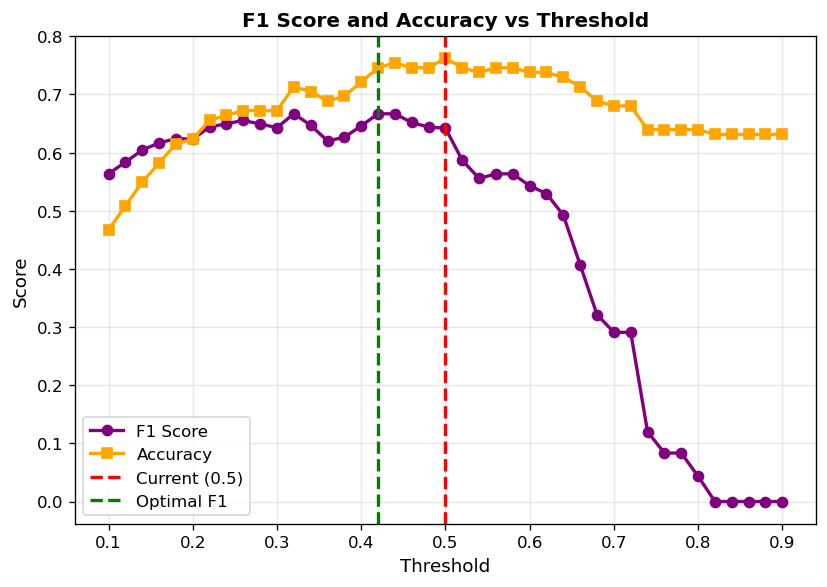


CLINICAL RECOMMENDATION:
Current threshold=0.5 gives: Sensitivity=57.8%, Precision=72.2%, F1=0.642

If you want to prioritize:
  - High confidence in 'Good' predictions -> Keep threshold >= 0.5 (higher precision)
  - Catch more recoverable patients -> Lower threshold to ~0.3-0.4 (higher sensitivity)
  - Balanced performance -> Use threshold=0.42


In [31]:
# Threshold optimization for binary classification
threshold_range = np.linspace(0.1, 0.9, 41)
threshold_metrics = []

for thresh in threshold_range:
    y_pred_thresh = (y_prob >= thresh).astype(int)

    tp_t = int(((y_pred_thresh == 1) & (y_true == 1)).sum())
    tn_t = int(((y_pred_thresh == 0) & (y_true == 0)).sum())
    fp_t = int(((y_pred_thresh == 1) & (y_true == 0)).sum())
    fn_t = int(((y_pred_thresh == 0) & (y_true == 1)).sum())

    sens_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    f1_t = 2 * sens_t * prec_t / (sens_t + prec_t) if (sens_t + prec_t) > 0 else 0
    acc_t = (tp_t + tn_t) / (tp_t + tn_t + fp_t + fn_t)
    specificity_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0

    threshold_metrics.append({
        "Threshold": thresh,
        "Sensitivity": sens_t,
        "Specificity": specificity_t,
        "Precision": prec_t,
        "F1": f1_t,
        "Accuracy": acc_t,
    })

threshold_df = pd.DataFrame(threshold_metrics)

# Find optimal threshold by F1 criterion
optimal_f1_idx = threshold_df["F1"].idxmax()

print("=" * 80)
print("THRESHOLD OPTIMIZATION ANALYSIS")
print("=" * 80)
print(f"\nCurrent model (threshold=0.5):")
print(f"  Sensitivity: {sensitivity:.3f} | Precision: {precision:.3f} | F1: {f1_score:.3f}")

print("\n\nOptimal threshold (F1 criterion):")
print(
    f"  Threshold={threshold_df.loc[optimal_f1_idx, 'Threshold']:.2f} -> "
    f"F1={threshold_df.loc[optimal_f1_idx, 'F1']:.3f}, "
    f"Sensitivity={threshold_df.loc[optimal_f1_idx, 'Sensitivity']:.3f}, "
    f"Precision={threshold_df.loc[optimal_f1_idx, 'Precision']:.3f}"
)

# Visualization: F1 Score and Accuracy vs Threshold
fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

ax.plot(threshold_df["Threshold"], threshold_df["F1"], "o-", label="F1 Score", linewidth=2, color="purple")
ax.plot(threshold_df["Threshold"], threshold_df["Accuracy"], "s-", label="Accuracy", linewidth=2, color="orange")
ax.axvline(x=0.5, color="red", linestyle="--", linewidth=2, label="Current (0.5)")
ax.axvline(x=threshold_df.loc[optimal_f1_idx, "Threshold"], color="green", linestyle="--", linewidth=2, label="Optimal F1")
ax.set_xlabel("Threshold", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("F1 Score and Accuracy vs Threshold", fontsize=12, fontweight="bold")
ax.legend(loc="best")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CLINICAL RECOMMENDATION:")
print("=" * 80)
print(f"Current threshold=0.5 gives: Sensitivity={sensitivity:.1%}, Precision={precision:.1%}, F1={f1_score:.3f}")
print(f"\nIf you want to prioritize:")
print("  - High confidence in 'Good' predictions -> Keep threshold >= 0.5 (higher precision)")
print("  - Catch more recoverable patients -> Lower threshold to ~0.3-0.4 (higher sensitivity)")
print(f"  - Balanced performance -> Use threshold={threshold_df.loc[optimal_f1_idx, 'Threshold']:.2f}")
print("=" * 80)

In [32]:
# 5-fold stratified CV for the same statsmodels GLM pipeline.
cv_base_df = training_dataframe.copy()
if "Outcome_binary" not in cv_base_df.columns:
    cv_base_df["Outcome_binary"] = cv_base_df["Outcome"].map(outcome_mapping)

if cv_base_df["Outcome_binary"].isna().any():
    raise ValueError("Outcome_binary contains missing labels; cannot run CV.")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=12345)
cv_rows = []

for fold_idx, (train_index, valid_index) in enumerate(
    skf.split(cv_base_df, cv_base_df["Outcome_binary"]),
    start=1,
):
    fold_train_raw = cv_base_df.iloc[train_index].copy()
    fold_valid_raw = cv_base_df.iloc[valid_index].copy()

    fold_train_model, fold_fill_values = prepare_modeling_features(fold_train_raw)
    fold_valid_model, _ = prepare_modeling_features(
        fold_valid_raw,
        numeric_fill_values=fold_fill_values,
    )

    fold_predictors = [col for col in predictor_columns if col in fold_train_model.columns]
    fold_formula = "Outcome_binary ~ " + " + ".join([f'Q("{col}")' for col in fold_predictors])

    fold_model = smf.glm(
        formula=fold_formula,
        data=fold_train_model,
        family=sm.families.Binomial(link=sm.families.links.Logit()),
        missing="raise",
    ).fit(maxiter=100, tol=1e-8)

    y_valid_true = fold_valid_model["Outcome_binary"].astype(int)
    y_valid_prob = fold_model.predict(fold_valid_model)
    y_valid_pred = (y_valid_prob >= 0.5).astype(int)

    tp_fold = int(((y_valid_pred == 1) & (y_valid_true == 1)).sum())
    tn_fold = int(((y_valid_pred == 0) & (y_valid_true == 0)).sum())
    fp_fold = int(((y_valid_pred == 1) & (y_valid_true == 0)).sum())
    fn_fold = int(((y_valid_pred == 0) & (y_valid_true == 1)).sum())

    accuracy_fold = float((y_valid_pred == y_valid_true).mean())
    sensitivity_fold = tp_fold / (tp_fold + fn_fold) if (tp_fold + fn_fold) > 0 else float("nan")
    specificity_fold = tn_fold / (tn_fold + fp_fold) if (tn_fold + fp_fold) > 0 else float("nan")
    precision_fold = tp_fold / (tp_fold + fp_fold) if (tp_fold + fp_fold) > 0 else float("nan")
    f1_fold = (
        2 * sensitivity_fold * precision_fold / (sensitivity_fold + precision_fold)
        if (sensitivity_fold + precision_fold) > 0
        else float("nan")
    )

    try:
        auc_fold = float(roc_auc_score(y_valid_true, y_valid_prob))
    except ValueError:
        auc_fold = float("nan")

    cv_rows.append(
        {
            "Fold": fold_idx,
            "N_valid": len(fold_valid_model),
            "Accuracy": accuracy_fold,
            "AUC": auc_fold,
            "Sensitivity": sensitivity_fold,
            "Specificity": specificity_fold,
            "Precision": precision_fold,
            "F1": f1_fold,
        }
    )

cv_fold_df = pd.DataFrame(cv_rows)
metric_columns = ["Accuracy", "AUC", "Sensitivity", "Specificity", "Precision", "F1"]

cv_summary_df = pd.DataFrame(
    {
        "Metric": metric_columns,
        "Mean": [cv_fold_df[col].mean() for col in metric_columns],
        "Std": [cv_fold_df[col].std(ddof=1) for col in metric_columns],
        "Min": [cv_fold_df[col].min() for col in metric_columns],
        "Max": [cv_fold_df[col].max() for col in metric_columns],
    }
)
cv_summary_df["Mean ± SD"] = cv_summary_df.apply(
    lambda row: f"{row['Mean']:.3f} +/- {row['Std']:.3f}",
    axis=1,
)

print("=" * 72)
print("5-FOLD STRATIFIED CV RESULTS (statsmodels logistic GLM, threshold=0.5)")
print("=" * 72)
print("\nSummary across folds:")
display(cv_summary_df[["Metric", "Mean ± SD", "Min", "Max"]].round(3))

5-FOLD STRATIFIED CV RESULTS (statsmodels logistic GLM, threshold=0.5)

Summary across folds:


,Metric,Mean ± SD,Min,Max
0,Accuracy,0.700 +/- 0.036,0.645,0.744
1,AUC,0.752 +/- 0.031,0.722,0.795
2,Sensitivity,0.564 +/- 0.080,0.489,0.667
3,Specificity,0.780 +/- 0.070,0.658,0.831
4,Precision,0.607 +/- 0.052,0.519,0.652
5,F1,0.581 +/- 0.047,0.543,0.659


In [33]:
import sys
from pathlib import Path

import numpy as np

# Add official scorer helpers to import path.
scoring_helper_path = (Path.cwd() / "official_scoring_metric").resolve()
if str(scoring_helper_path) not in sys.path:
    sys.path.insert(0, str(scoring_helper_path))

from helper_code import save_challenge_outputs


def estimate_cpc_from_poor_probability(
    poor_outcome_probability: float,
    median_cpc_good: float,
    median_cpc_poor: float,
) -> float:
    """Estimate CPC as a probability-weighted expectation clipped to valid range [1, 5].

    Args:
        poor_outcome_probability: Predicted probability of Poor outcome.
        median_cpc_good: Median CPC among Good-outcome training rows.
        median_cpc_poor: Median CPC among Poor-outcome training rows.

    Returns:
        Estimated CPC value.
    """
    estimated_cpc = (1.0 - poor_outcome_probability) * median_cpc_good + (
        poor_outcome_probability * median_cpc_poor
    )
    return float(np.clip(estimated_cpc, 1.0, 5.0))


def export_challenge_output_files(
    input_dataframe: pd.DataFrame,
    model_result,
    predictor_names: list[str],
    learned_fill_values: dict[str, float],
    output_root: Path,
    decision_threshold_good: float = 0.42,
) -> list[Path]:
    """Write official Challenge output files (one txt file per patient).

    Args:
        input_dataframe: Raw dataframe containing patient metadata and source_file.
        model_result: Fitted statsmodels GLM result object.
        predictor_names: Predictor columns expected by the model.
        learned_fill_values: Numeric fill values learned on training data.
        output_root: Root output folder where patient subfolders are created.
        decision_threshold_good: Threshold on P(Good) for binary Good/Poor output.

    Returns:
        List of written output file paths.
    """
    prepared_dataframe, _ = prepare_modeling_features(
        input_dataframe,
        numeric_fill_values=learned_fill_values,
    )

    good_outcome_probability = model_result.predict(prepared_dataframe[predictor_names]).clip(0, 1)
    poor_outcome_probability = 1.0 - good_outcome_probability
    predicted_good_label = (good_outcome_probability >= decision_threshold_good).astype(int)

    for threshold in [0.42, 0.50]:
        labels_at_threshold = (good_outcome_probability >= threshold).astype(int)
        count_good = int(labels_at_threshold.sum())
        count_total = int(len(labels_at_threshold))
        print(
            f"Threshold={threshold:.2f}: "
            f"Good={count_good}/{count_total} ({count_good / count_total:.1%})"
        )

    cpc_reference = modeling_train_df[["Outcome_binary", "CPC"]].dropna().copy()
    median_cpc_good = float(cpc_reference.loc[cpc_reference["Outcome_binary"] == 1, "CPC"].median())
    median_cpc_poor = float(cpc_reference.loc[cpc_reference["Outcome_binary"] == 0, "CPC"].median())

    if np.isnan(median_cpc_good):
        median_cpc_good = 2.0
    if np.isnan(median_cpc_poor):
        median_cpc_poor = 4.0

    output_root.mkdir(parents=True, exist_ok=True)
    written_paths: list[Path] = []

    for row_index in prepared_dataframe.index:
        source_file = prepared_dataframe.loc[row_index, "source_file"]
        patient_id = Path(str(source_file)).stem

        # Helper expects outcome coding Good=0, Poor=1.
        outcome_for_file = 0 if int(predicted_good_label.loc[row_index]) == 1 else 1
        poor_probability_value = float(poor_outcome_probability.loc[row_index])
        estimated_cpc = estimate_cpc_from_poor_probability(
            poor_probability_value,
            median_cpc_good,
            median_cpc_poor,
        )

        output_file_path = output_root / patient_id / f"{patient_id}.txt"
        output_file_path.parent.mkdir(parents=True, exist_ok=True)

        save_challenge_outputs(
            str(output_file_path),
            patient_id,
            outcome_for_file,
            poor_probability_value,
            estimated_cpc,
        )
        written_paths.append(output_file_path)

    return written_paths


output_directory = Path("official_scoring_metric") / "demo_data" / "outputs_generated"
written_output_files = export_challenge_output_files(
    input_dataframe=test_df,
    model_result=logit_model,
    predictor_names=predictor_columns,
    learned_fill_values=numeric_fill_values,
    output_root=output_directory,
    decision_threshold_good=0.42,
)

print(f"Wrote {len(written_output_files)} prediction files to: {output_directory}")
display(pd.DataFrame({"output_file": [str(path) for path in written_output_files[:5]]}))

Threshold=0.42: Good=48/122 (39.3%)
Threshold=0.50: Good=36/122 (29.5%)
Wrote 122 prediction files to: official_scoring_metric\demo_data\outputs_generated


,output_file
0,official_scoring_metric\demo_data\outputs_gene...
1,official_scoring_metric\demo_data\outputs_gene...
2,official_scoring_metric\demo_data\outputs_gene...
3,official_scoring_metric\demo_data\outputs_gene...
4,official_scoring_metric\demo_data\outputs_gene...


In [34]:
from pathlib import Path


def export_ground_truth_labels_for_scoring(
    labels_source_dataframe: pd.DataFrame,
    output_root: Path,
) -> list[Path]:
    """Export ground-truth labels from test_df into scorer-compatible txt files.

    Args:
        labels_source_dataframe: DataFrame containing source_file, Outcome, CPC, and optionally Hospital.
        output_root: Target folder where patient subfolders and txt files are created.

    Returns:
        List of written label file paths.
    """
    required_columns = {"source_file", "Outcome", "CPC"}
    missing_columns = required_columns - set(labels_source_dataframe.columns)
    if missing_columns:
        raise ValueError(f"Missing required columns for label export: {sorted(missing_columns)}")

    labels_dataframe = labels_source_dataframe.dropna(subset=["Outcome", "CPC"]).copy()
    output_root.mkdir(parents=True, exist_ok=True)

    written_files: list[Path] = []
    for _, row in labels_dataframe.iterrows():
        patient_id = Path(str(row["source_file"])).stem
        hospital_value = row["Hospital"] if "Hospital" in labels_dataframe.columns else "A"

        if pd.isna(hospital_value):
            hospital_value = "A"

        outcome_text = str(row["Outcome"]).strip()
        if outcome_text not in {"Good", "Poor"}:
            raise ValueError(f"Unexpected Outcome value for patient {patient_id}: {outcome_text}")

        cpc_value = float(row["CPC"])

        patient_folder = output_root / patient_id
        patient_folder.mkdir(parents=True, exist_ok=True)
        label_file = patient_folder / f"{patient_id}.txt"

        label_text = (
            f"Patient: {patient_id}\n"
            f"Hospital: {hospital_value}\n"
            f"Outcome: {outcome_text}\n"
            f"CPC: {cpc_value:.1f}\n"
        )
        label_file.write_text(label_text, encoding="utf-8")
        written_files.append(label_file)

    return written_files


labels_output_directory = Path("official_scoring_metric") / "demo_data" / "labels_generated_from_test_df"
written_label_files = export_ground_truth_labels_for_scoring(
    labels_source_dataframe=test_df,
    output_root=labels_output_directory,
)

print(f"Wrote {len(written_label_files)} label files to: {labels_output_directory}")
display(pd.DataFrame({"label_file": [str(path) for path in written_label_files[:5]]}))

Wrote 122 label files to: official_scoring_metric\demo_data\labels_generated_from_test_df


,label_file
0,official_scoring_metric\demo_data\labels_gener...
1,official_scoring_metric\demo_data\labels_gener...
2,official_scoring_metric\demo_data\labels_gener...
3,official_scoring_metric\demo_data\labels_gener...
4,official_scoring_metric\demo_data\labels_gener...


In [42]:
from sklearn.model_selection import StratifiedKFold

# Import the official scorer functions.
scoring_path = (Path.cwd() / "official_scoring_metric").resolve()
if str(scoring_path) not in sys.path:
    sys.path.insert(0, str(scoring_path))

from evaluate_model import compute_auc, compute_challenge_score


def compute_cv_challenge_score(
    base_dataframe: pd.DataFrame,
    predictor_names: list[str],
    splits: int = 5,
    random_seed: int = 12345,
    max_iterations: int = 100,
) -> tuple[float, float, pd.DataFrame]:
    """Compute out-of-fold Challenge score with 5-fold stratified CV.

    Args:
        base_dataframe: Dataframe containing Outcome_binary and Hospital columns.
        predictor_names: Predictor columns used by the GLM model.
        splits: Number of CV folds.
        random_seed: Random seed for reproducible fold assignment.
        max_iterations: Maximum GLM fitting iterations.

    Returns:
        Tuple with Challenge score, AUROC, and per-row OOF predictions.
    """
    if "Outcome_binary" not in base_dataframe.columns:
        raise ValueError("Outcome_binary is required for CV challenge scoring.")
    if "Hospital" not in base_dataframe.columns:
        raise ValueError("Hospital is required for Challenge score calculation.")

    cv_dataframe = base_dataframe.copy().reset_index(drop=True)
    cv_dataframe["oof_good_probability"] = np.nan

    skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=random_seed)

    for fold_number, (train_index, valid_index) in enumerate(
        skf.split(cv_dataframe, cv_dataframe["Outcome_binary"]),
        start=1,
    ):
        fold_train_raw = cv_dataframe.iloc[train_index].copy()
        fold_valid_raw = cv_dataframe.iloc[valid_index].copy()

        fold_train_model, fold_fill_values = prepare_modeling_features(fold_train_raw)
        fold_valid_model, _ = prepare_modeling_features(
            fold_valid_raw,
            numeric_fill_values=fold_fill_values,
        )

        fold_predictors = [column for column in predictor_names if column in fold_train_model.columns]
        fold_formula = "Outcome_binary ~ " + " + ".join([f'Q("{column}")' for column in fold_predictors])

        fold_model = smf.glm(
            formula=fold_formula,
            data=fold_train_model,
            family=sm.families.Binomial(link=sm.families.links.Logit()),
            missing="raise",
        ).fit(maxiter=max_iterations, tol=1e-8)

        fold_valid_prob_good = fold_model.predict(fold_valid_model).clip(0, 1)
        cv_dataframe.loc[valid_index, "oof_good_probability"] = fold_valid_prob_good.to_numpy()

    if cv_dataframe["oof_good_probability"].isna().any():
        raise ValueError("OOF probabilities contain missing values after CV.")

    # Official scorer expects labels and probabilities for Poor outcome:
    # labels: Good=0, Poor=1 and probability=P(Poor).
    labels_poor_binary = (1 - cv_dataframe["Outcome_binary"].astype(int)).to_numpy()
    probabilities_poor = (1.0 - cv_dataframe["oof_good_probability"]).to_numpy()
    hospitals = cv_dataframe["Hospital"].astype(str).to_list()

    cv_challenge = float(compute_challenge_score(labels_poor_binary, probabilities_poor, hospitals))
    cv_auroc, cv_auprc = compute_auc(labels_poor_binary, probabilities_poor)

    print("=" * 72)
    print(f"{splits}-fold OOF Challenge Score: {cv_challenge:.3f}")
    print(f"{splits}-fold OOF AUROC: {cv_auroc:.3f}")
    print(f"{splits}-fold OOF AUPRC: {cv_auprc:.3f}")
    print("=" * 72)

    return cv_challenge, float(cv_auroc), cv_dataframe


cv_challenge_score, cv_oof_auroc, cv_oof_predictions_df = compute_cv_challenge_score(
    base_dataframe=training_dataframe,
    predictor_names=predictor_columns,
    splits=5,
    random_seed=12345,
)

5-fold OOF Challenge Score: 0.369
5-fold OOF AUROC: 0.754
5-fold OOF AUPRC: 0.823
